# 06. Model Comparison

## Objective

This notebook independently trains and compares the selected Logistic Regression baseline and the XGBoost advanced model using the same Cleveland dataset, target definition, stratified 80:20 train/test split, leakage-safe preprocessing, and evaluation criteria established earlier in the project.

The notebook does **not** import or execute another notebook. All data preparation, model construction, prediction generation, and evaluation are performed independently through the shared `src/preprocessing.py` and `src/evaluation.py` modules.

## 2. Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "src" / "preprocessing.py").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root containing src/preprocessing.py")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import load_data, prepare_features_target, get_feature_groups, validate_columns
from src.models import get_baseline_models, create_xgboost_model, build_model_pipelines, get_cv_scoring, RANDOM_STATE
from src.evaluation import evaluate_model, compare_model_metrics
from src.visualization import plot_confusion_matrix, plot_model_comparison
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split


## 3. Load and Prepare the Dataset

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "processed.cleveland.data"
df = load_data(DATA_PATH)
validate_columns(df)
X, y = prepare_features_target(df)
groups = get_feature_groups()
numerical_features = groups["numerical"]
categorical_features = groups["categorical"]

print("Dataset shape:", df.shape)
print("Predictor shape:", X.shape)
print("Target distribution:", y.value_counts().sort_index().to_dict())


Dataset shape: (303, 14)
Predictor shape: (303, 13)
Target distribution: {0: 164, 1: 139}


## 4. Stratified Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training target:", y_train.value_counts().sort_index().to_dict())
print("Test target:", y_test.value_counts().sort_index().to_dict())


Training shape: (242, 13)
Test shape: (61, 13)
Training target: {0: 131, 1: 111}
Test target: {0: 33, 1: 28}


## 5. Define the Models

The model settings below reproduce the established baseline Logistic Regression configuration and the XGBoost advanced-model configuration. Both models use the same reusable preprocessing pipeline.

In [4]:
models = get_baseline_models()
models = {"Logistic Regression": models["Logistic Regression"], "XGBoost": create_xgboost_model()}
pipelines = build_model_pipelines(
    models, numerical_features=numerical_features, categorical_features=categorical_features
)


## 6. Five-Fold Cross-Validation

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = get_cv_scoring()
cv_results = {}
for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, scoring=scoring,
        error_score="raise", return_train_score=False
    )
    cv_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring}
    cv_results[name]["ROC-AUC SD"] = scores["test_roc_auc"].std(ddof=0)
cv_comparison = pd.DataFrame(cv_results).T
display(cv_comparison.round(4))


,accuracy,precision,recall,specificity,f1,roc_auc,ROC-AUC SD
Logistic Regression,0.8471,0.8768,0.7834,0.9003,0.8245,0.9025,0.0144
XGBoost,0.8016,0.7848,0.7834,0.8165,0.7825,0.8664,0.0330


## 7. Fit Both Models and Generate Independent Test Predictions

In [6]:
fitted_models = {}
evaluation_results = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    evaluation_results[name] = evaluate_model(pipeline, X_test, y_test)

# Explicit variables make the notebook self-contained and prevent hidden dependencies.
y_pred_lr = evaluation_results["Logistic Regression"]["y_pred"]
y_pred_xgb = evaluation_results["XGBoost"]["y_pred"]
cm_lr = evaluation_results["Logistic Regression"]["confusion_matrix"]
cm_xgb = evaluation_results["XGBoost"]["confusion_matrix"]


## 8. Held-Out Test-Set Metric Comparison

In [7]:
test_metric_results = {
    name: result["metrics"]
    for name, result in evaluation_results.items()
}
test_comparison = compare_model_metrics(test_metric_results)
display(test_comparison.round(4))


,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC
Logistic Regression,0.8852,0.8387,0.9286,0.8485,0.8814,0.9665
XGBoost,0.9016,0.8438,0.9643,0.8485,0.9000,0.9545


## 9. Confusion Matrices and Classification Reports

Logistic Regression confusion matrix:
[[28  5]
 [ 2 26]]

Logistic Regression classification report:
              precision    recall  f1-score   support

           0     0.9333    0.8485    0.8889        33
           1     0.8387    0.9286    0.8814        28

    accuracy                         0.8852        61
   macro avg     0.8860    0.8885    0.8851        61
weighted avg     0.8899    0.8852    0.8854        61

XGBoost confusion matrix:
[[28  5]
 [ 1 27]]

XGBoost classification report:
              precision    recall  f1-score   support

           0     0.9655    0.8485    0.9032        33
           1     0.8438    0.9643    0.9000        28

    accuracy                         0.9016        61
   macro avg     0.9046    0.9064    0.9016        61
weighted avg     0.9096    0.9016    0.9017        61



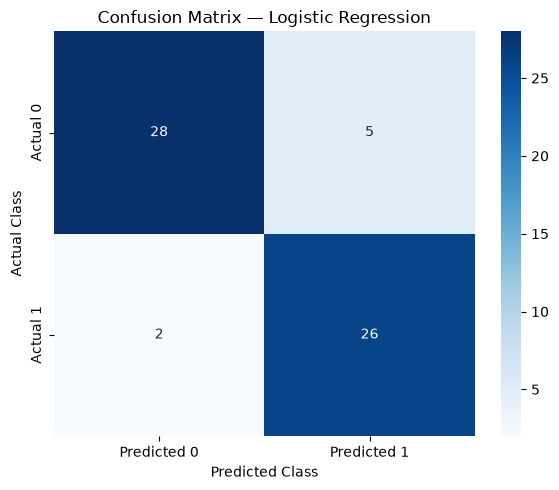

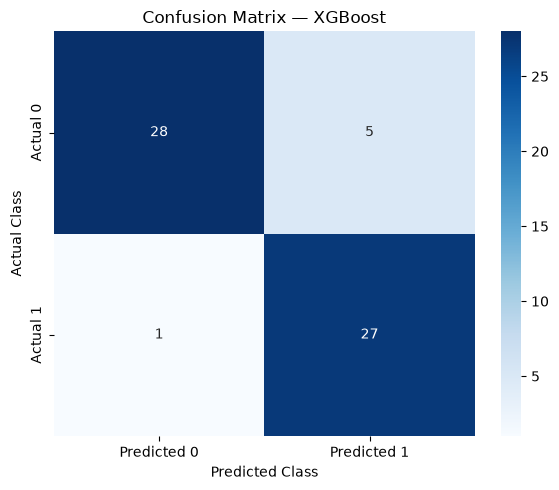

In [11]:
print("Logistic Regression confusion matrix:")
print(cm_lr)
fig, ax = plot_confusion_matrix(cm_lr, title="Confusion Matrix — Logistic Regression")
print("\nLogistic Regression classification report:")
print(evaluation_results["Logistic Regression"]["classification_report"])

print("XGBoost confusion matrix:")
print(cm_xgb)
fig, ax = plot_confusion_matrix(cm_xgb, title="Confusion Matrix — XGBoost")
print("\nXGBoost classification report:")
print(evaluation_results["XGBoost"]["classification_report"])


## 10. Direct Metric Comparison

,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,ROC-AUC Difference vs LR
Logistic Regression,0.8852,0.8387,0.9286,0.8485,0.8814,0.9665,0.0000
XGBoost,0.9016,0.8438,0.9643,0.8485,0.9000,0.9545,-0.0119


Selected baseline criterion: mean cross-validation ROC-AUC
Logistic Regression CV ROC-AUC: 0.9025
XGBoost CV ROC-AUC: 0.8664


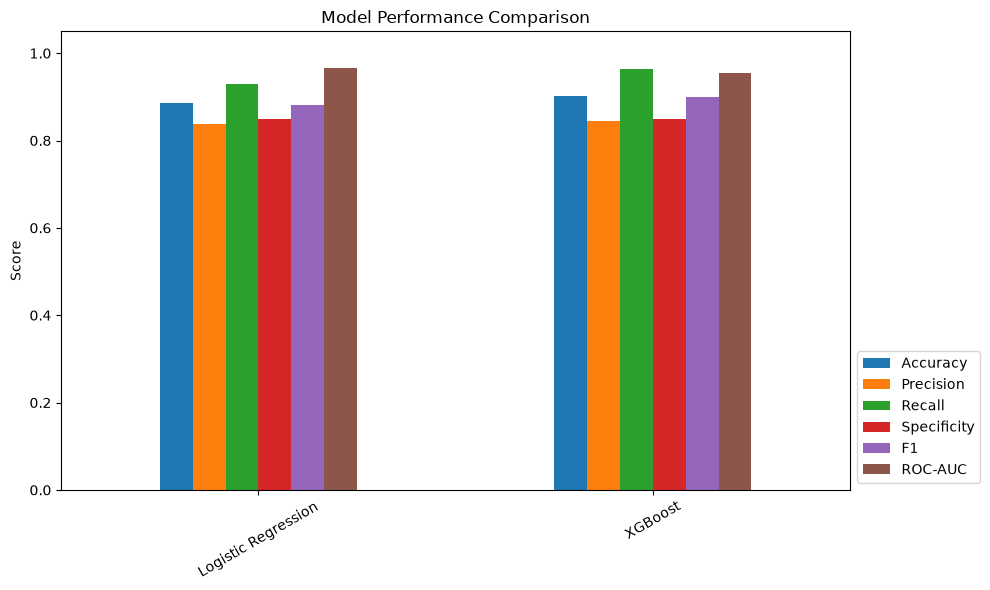

In [9]:
comparison = test_comparison.copy()
comparison["ROC-AUC Difference vs LR"] = comparison["ROC-AUC"] - comparison.loc["Logistic Regression", "ROC-AUC"]
display(comparison.round(4))

print("Selected baseline criterion: mean cross-validation ROC-AUC")
print(f"Logistic Regression CV ROC-AUC: {cv_comparison.loc['Logistic Regression', 'roc_auc']:.4f}")
print(f"XGBoost CV ROC-AUC: {cv_comparison.loc['XGBoost', 'roc_auc']:.4f}")

fig, ax = plot_model_comparison(test_comparison)


## 11. Reproducibility and Independence Checks

The comparison is based on the same 303-record Cleveland dataset, binary target conversion, stratified 80:20 split, and leakage-safe preprocessing used in the preceding modelling notebooks. This notebook independently creates `y_test`, both fitted pipelines, both prediction arrays, and both confusion matrices.

The test-set metrics describe this particular held-out sample and should not be interpreted as evidence of clinical validity or universal model superiority.

In [10]:
assert X.shape == (303, 13)
assert X_train.shape == (242, 13)
assert X_test.shape == (61, 13)
assert y_train.value_counts().sort_index().to_dict() == {0: 131, 1: 111}
assert y_test.value_counts().sort_index().to_dict() == {0: 33, 1: 28}
assert y_pred_lr.shape == y_test.shape
assert y_pred_xgb.shape == y_test.shape
assert cm_lr.shape == (2, 2)
assert cm_xgb.shape == (2, 2)

print("Reproducibility checks: PASSED")
print("Evaluation source: src/evaluation.py")
print("Preprocessing source: src/preprocessing.py")


Reproducibility checks: PASSED
Evaluation source: src/evaluation.py
Preprocessing source: src/preprocessing.py


## 12. Model Comparison Conclusion

Logistic Regression and XGBoost were evaluated under the same data split, preprocessing workflow, and evaluation framework. The cross-validation ROC-AUC values provide the primary basis for the project-level baseline selection, while the held-out test metrics show how each fitted model performed on the untouched test subset.

The comparison is intentionally limited to the experimental conditions used in this project. Differences between the two models should therefore be discussed in relation to the Cleveland dataset, the selected hyperparameters, the fixed split, and the evaluation procedure rather than generalized beyond the experiment.